In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit, differential_evolution
import warnings

In [2]:
#Load dataset
df = pd.read_csv('../data.csv')

In [3]:
#Extract data
xData = df['Final concentration of M.B. (Cf) (mg/l)'].values
yData = df['amount of adsorbed by adsorbent at equilibrium (qe) (mg/g)'].values

In [4]:
# Sips model
def func(x, KS, aS, bS):
    return (KS * (x**bS))/(1+aS*(x**bS))

In [5]:
#Error function
def sum_of_squared_error(parameter_tuple):
    warnings.filterwarnings("ignore")
    val = func(xData, *parameter_tuple)
    return np.sum((yData - val) ** 2.0)

In [6]:
#Initial parameter estimation using generic algorithm
def generate_initial_parameters():
    parameter_bounds=[]
    parameter_bounds.append([0.0001, 1000]) #KS bounds
    parameter_bounds.append([0.0001, 100]) #aS bounds
    parameter_bounds.append([0.1, 5]) #bS bounds 

    result = differential_evolution(sum_of_squared_error, parameter_bounds, seed=3)
    return result.x

In [7]:
#Generate initial parameters
genetic_parameters = generate_initial_parameters()

In [8]:
#Curve fitting
fitted_parameters, pcov = curve_fit(func, xData, yData, genetic_parameters, maxfev=10000)

KS, aS, bS = fitted_parameters
print(f'Parameters (KS, aS, bS)=({KS}, {aS}, {bS})')

Parameters (KS, aS, bS)=(0.9267399948326984, 0.1433200197433672, 0.699961822971629)


In [9]:
#Predictions
model_predictions = func(xData, *fitted_parameters)

In [10]:
#Error Calculation
absolute_error = abs(model_predictions - yData)
squared_error = np.square(absolute_error)
mse = np.mean(squared_error)
rmse = np.sqrt(mse)
n=len(yData)
p=3 #no. of parameters

hybrid = (100.0/(n-p)) * np.sum(squared_error/yData)
mpsd = 100.0*np.sqrt((1.0/(n-p)) * np.sum(np.square(absolute_error/yData)))
chi_square = np.sum(squared_error/yData)

In [11]:
#Output results
print('ERRSQ:      ', np.sum(squared_error))
print('RMSE:       ', rmse)
print('HYBRID:     ', hybrid)
print('EABS:       ', np.sum(absolute_error))
print('MPSD:       ', mpsd)
print('Chi-square: ', chi_square)

ERRSQ:       0.0021004209888985867
RMSE:        0.016203475664570345
HYBRID:      0.1386475723730317
EABS:        0.11179630034810693
MPSD:        9.425331383195537
Chi-square:  0.006932378618651586


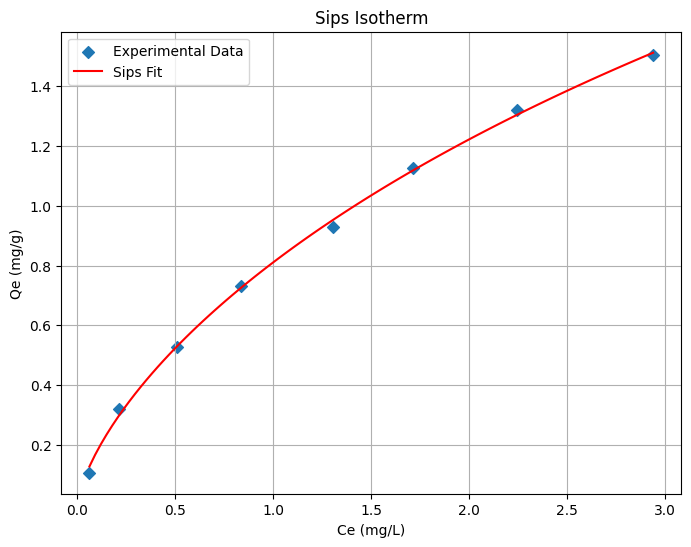

In [12]:
#Plotting
def plot():
    plt.figure(figsize=(8,6))

    #Scatter plot
    plt.scatter(xData, yData, marker='D', label='Experimental Data')

    #Model Curve
    xModel = np.linspace(min(xData), max(xData), 100)
    yModel = func(xModel, *fitted_parameters)

    plt.plot(xModel, yModel,color='red', label='Sips Fit')

    plt.title('Sips Isotherm')
    plt.xlabel('Ce (mg/L)')
    plt.ylabel('Qe (mg/g)')
    plt.legend()
    plt.grid()

    plt.show()

plot()